In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.linalg as la

In [2]:
X01 = np.array([[0, 1, 0],
                    [1, 0, 0],
                    [0, 0, 0]], dtype = complex)
    
Y01 = np.array([[0, -1j, 0],
                    [1j, 0, 0],
                    [0, 0, 0]], dtype = complex)
    
X12 = np.array([[0, 0, 0],
                    [0, 0, 1],
                    [0, 1, 0]], dtype = complex)
    
Y12 = np.array([[0, 0, 0],
                    [0, 0, -1j],
                    [0, 1j, 0]], dtype = complex)

In [3]:
rho0 = np.array([[1, 0, 0],
                [0, 0, 0],
                [0, 0, 0]], 
               dtype = complex)

In [4]:
w01 = 2*np.pi * 4.3910e+09
anh = 2*np.pi * (-1.8100e+08)
lamb01 = 1.0
lamb12 = 1.0

w12 = w01 + anh

In [5]:
def constantWF(_t):
    return 1
def gaussianWF(_t, _mu, _sigma):
    return np.exp(-(_t - _mu)**2/(2*_sigma**2))

In [6]:
def get_H(_t, _wd, _V0, _phi, _s):
    dw01 = w01 - _wd
    dw12 = w12 - _wd
    I = np.cos(_phi)
    Q = np.sin(_phi)
    return (_V0/2) * _s(_t) * (lamb01 * ( (-I * np.sin(dw01 * _t) + Q * np.cos(dw01 * _t)) * Y01
                                       -(I * np.cos(dw01 * _t) + Q * np.sin(dw01 * _t)) * X01)
                             + lamb12 * ( (-I * np.sin(dw12 * _t) + Q * np.cos(dw12 * _t)) * Y12
                                       -(I * np.cos(dw12 * _t) + Q * np.sin(dw12 * _t)) * X12))
def get_U(_t, _dt, _wd, _V0, _phi, _s):
    return la.expm(-1j * get_H(_t, _wd, _V0, _phi, _s) * _dt)

In [9]:
V0 = 1
phi = 0
def s(_t):
    return constantWF(_t)
get_U(0,1e-12, w01, V0, phi,s)

array([[ 1.00e+00+0.e+00j,  0.00e+00+5.e-13j, -1.25e-25+0.e+00j],
       [-0.00e+00+5.e-13j,  1.00e+00+0.e+00j, -0.00e+00+5.e-13j],
       [-1.25e-25+0.e+00j,  0.00e+00+5.e-13j,  1.00e+00+0.e+00j]])

In [14]:
V0 = 1.0
wd = w01+w12 #+ 2*np.pi * 0.001e9
phi = 0
def s(_t):
    return constantWF(_t)
    
T = np.pi/(V0 * lamb01)
steps = 100
times = np.linspace(0, T, steps)
dt = T/float(steps)

rho = rho0
pops = np.zeros((3, steps))

for i in range(steps):
    U = get_U(times[i], dt, wd, V0, phi, s)
    rho = np.matmul(U, np.matmul(rho, U.T.conj()))
    pops[:, i] = np.diag(np.real(rho))
    

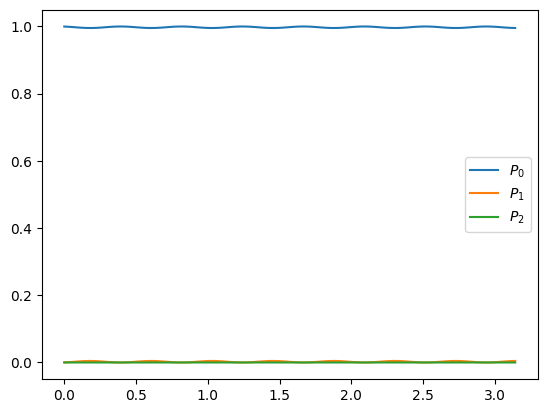

In [15]:
plt.plot(times, pops[0,:], label = r'$P_0$')
plt.plot(times, pops[1,:], label = r'$P_1$')
plt.plot(times, pops[2,:], label = r'$P_2$')
plt.legend()

In [16]:
def simulate_01(_steps, _wd, _V0, _phi, _s):
    T = np.pi/(V0 * lamb1)
    times = np.linspace(0, T, _steps)
    dt = T/float(steps)

    rho = rho0
    for i in range(steps):
        U = get_U(times[i], dt, _wd, _V0, _phi, _s)
        rho = np.matmul(U, np.matmul(rho, U.T.conj()))
    return np.diag(np.real(rho))
    

In [17]:
V0 = 1.0
phi = 0.0
def s(_t):
    return constantWF(_t)
steps = 100 

dw_steps = 1
dw_lim = 0
dw = np.linspace(-dw_lim, dw_lim, dw_steps)
pops = np.zeros((3, dw_steps))


for i in range(dw_steps):
    pops[:,i] = simulate_01(steps, w01+dw[i], V0, phi, s)



NameError: name 'lamb1' is not defined

In [ ]:
plt.plot(dw, pops[0,:])